# Laboration 2 - Dynamic Programming
    Course: Reinforcement Learning 4MA903
    Semester: HT24
    Author: Björn Lindenberg
---
## Lab Instructions
* For a completed laboration and a passed grade, every problem must have been sufficiently solved and every question   answered. 
* It is recommended to divide up your definitions and computations, and add any cells you need (both markdown and code). 
* Feel free to organize this notebook in any way that best suits your workflow, this includes moving cells around (even code cells given in problem definitions). However to make grading easier, just make sure to provide explanations, graphs and analysis in headings named **Solution** after each problem definition. Provide math, explanations and arguments in markdown (not in code comments).
* Your overall solution of this laboration should be clearly presented, well-structured and uncluttered. Hence you should remove cells and computations that are irrelevant to your final report. Keep the mindset of presenting a crystal clear report on how to solve each problem.
        

## Introduction
In this laboration we will focus on dynamic programming algorithms in a tabular setting. The actual problems will be a Taxicab operation and two grid worlds. We'll be solving tasks in finite MDPs with an iterative approach, both for evaluation and control. This is used heavily in more advanced approximate algorithms such as in deep reinforcement learning. We'll also practice some simulation setup both to verify the theory and to gain confidence in implementing frameworks for solutions in tougher problems (such as in the next lab). 

---

# Part A - Howard's Taxicab Operation

In this section we're going to solve for optimal control of a ride-hailing operation. We consider the problem of a single taxi driver that handles three separate regions in some unnamed city, let's call them region A, B and C. At each decision point the driver has up to three different options (depending on the region). These options are:

1. Cruise in the hope of picking up a passenger by being hailed.
2. Drive to the nearest taxi stand and wait for passengers, e.g., at a local train station. 
3. Pull over and wait for a call from dispatch.

The driver has access to all options in region A and C, but only access to options 1 and 2 in region B. The question posed to us is which option to take in the different regions in order to maximize profit. We can imagine that there are probabilities for transitions between different regions, earned revenue and incurred expenses.

Modelling the problem as an RL problem, we put $s_0, s_1$ and $s_2$ to correspond to the different regions, i.e., which state the driver is in. Further, we model the available options as actions $a_0$, $a_1$ and $a_2$. We also have access to the full dynamics of the system which can be represented by the following table:
$$
\begin{array}{cccc}
\text{State} & \text{Action} & \text{Probabilities} & \text{Rewards} \\
s & a & p(\cdot \mid s, a) & r(\cdot \mid s, a) \\
& & \begin{matrix} s_0' & s_1' & s_2' \end{matrix}  & \begin{matrix} s_0' & s_1' & s_2' \end{matrix} \\
\hline & & & \\
s_0 & \begin{matrix}a_0 \\ a_1\\ a_2\end{matrix} &  \begin{bmatrix} 1/2 & 1/3 &  1/6 \\  3/8 & 1/4 & 3/8 \\ 1/16 & 5/16 & 5/8 \end{bmatrix} & \begin{bmatrix}7 & 3 & 5\\ 9 & 5 & 10\\ 4 & 8 & 4\end{bmatrix} \\
& & & \\
s_1 & \begin{matrix}a_0 \\ a_1 \end{matrix} & \begin{bmatrix} 3/8 & 1/8 & 1/2 \\ 3/16 & 1/16 & 3/4 \end{bmatrix} & \begin{bmatrix} 7 & 2 & 9\\ 4 & 10 & 4\end{bmatrix} \\
& & & \\
s_2 & \begin{matrix}a_0 \\ a_1\\ a_2\end{matrix} & \begin{bmatrix}1/2 & 1/4 & 1/4 \\ 3/8 & 1/2 & 1/8 \\ 3/16 & 1/16 & 3/4 \end{bmatrix} & \begin{bmatrix}4 & 5 & 7\\ 9 & 4 & 6\\ 4 & 8 & 10\end{bmatrix} \\
& & & 
\end{array}
$$
That is, for each state and action $(s, a)$ we can in the $p(\cdot \mid s, a)$-column read off the transition probabilities of ending up in another state $s'$ by the corresponding matrix row and column. We also see from the $r(\cdot \mid s, a)$-column that the observed reward for each transition $(s,a) \to s'$ is deterministic and the corresponding value is read in the same way. For example, if the driver is in state $s_1$ and takes action $a_1$ there is 1/16-probability of staying in state $s_1$ with an observed reward of $10$. 

___

### Problem 1. Taxicab Policy Iteration
In this problem we're going to implement policy iteration to solve for optimal control of the taxicab operation.

**Evaluation**: Instead of explicitly solving simultaneous linear Bellman equations, which can be done for this simple problem, we'll use the more RL-related approach suggested in the course literature by Sutton & Barto. So for a fixed policy $\pi$ we consider a sequence of approximate value functions $v_0, v_1, \dots$ and define a recurrence relation by the Bellman operator:
$$
v_{k+1}(s) := \sum_{a} \pi(a \mid s) \sum_{s', r} p(s', r \mid s,a) \left[r + \gamma v_k(s')\right].
$$

**Improvement**: Given an evaluated policy $\pi$ with known value function $v_\pi$ we may  extract a new deterministic *greedy* policy $\pi'$ by always choosing the action with the best expectation in each state (according to some fixed schedule for ties). By the policy improvement theorem this new policy must be as good or better than $\pi$. Explicitly we have 
$$
\pi'(s) := \text{argmax}_a \sum_{s', r} p(s', r \mid s,a) \left[r + \gamma v_{\pi}(s')\right].
$$

Since the problem only has three states we may view any value function $v$ as a 3-vector. Further, we may view a policy $\pi$ as a list of three vectors, each holding probabilities for a categorical distribution over actions in each state. In particular $\pi(s_0)$ and $\pi(s_2)$ will each have three probabilities (summing to one), whereas $\pi(s_1)$ is a vector with two probabilities. How to actually implement these abstractions is up to you. Further, in all tasks we'll use the discount factor $\gamma = 0.99$.

Our tasks in this problem are the following:

1. Implement policy evaluation as a function which takes a policy $\pi$ and returns an estimated value function $v_\pi$. Use the Bellman operator and let the sequence $v_0, v_1, \dots$ of iterated value functions be considered converged if $\lVert v_{k+1} - v_{k} \rVert_{\infty} < 10^{-3}$ and then return $v_{k+1}$.
2. Find and state $v_\pi$ for the random agent, i.e., evaluate the policy that uniformly samples actions in each state. 
3. Implement a function which generates a deterministic greedy policy from a given value function $v_\pi$. Implement policy iteration as a function which takes an initial policy $\pi_0$ and returns the optimal greedy policy $\pi_*$. The main loop of the function should give rise to a sequence $\pi_0, \pi_1, \dots, \pi_k, \dots$, by switching between evaluation of $\pi_{k}$ and extraction of a new improved and greedy policy $\pi_{k+1} := \pi_{k}'$. Return $\pi_k$ as soon as the sequence converges, i.e., whenever $\pi_{k+1} = \pi_{k}$. 
4. Solve the taxicab operation for an optimal deterministic policy $\pi_*$ and value function $v_*$.

### Solution

In [54]:
# Define all functions for problem 1
import numpy as np


def policy_eval(policy, P, R, gamma, eps=1e-3, max_iter=1e4):
    P_pi = np.sum(P * policy, axis=1)
    R_pi = np.sum(P * R * policy, axis=(1, 2))

    V = np.zeros(R_pi.shape)
    for k in range(int(max_iter)):
        print(V.shape)
        V_new = R_pi + gamma * P_pi @ V
        error_bound = gamma / (1 - gamma) * np.max(np.abs(V_new - V))
        V = V_new
        if error_bound < eps:
            return V
    raise RuntimeError(f"No convergence in max_iter")


def policy_improvement(V, P, R, gamma):
    Q = (P * (R + gamma * V)).sum(axis=2)
    return np.argmax(Q, axis=1)


def policy_iteration(P, R, gamma, eps=1e-3, max_iter=1e4, policy=None):
    if not policy:
        policy = np.zeros(len(P), dtype=int)

    while True:
        V = policy_eval(policy, P, R, gamma, eps, max_iter)
        new_policy = policy_improvement(V, P, R, gamma)

        if np.array_equal(new_policy, policy):
            return V, policy

        policy = new_policy


prob_s0 = [
    [1/2, 1/3, 1/6],
    [3/8, 1/4, 3/8],
    [1/16, 5/16, 5/8]
]
reward_s0 = [
    [7, 3, 5],
    [9, 5, 10],
    [4, 8, 4]
]
prob_s1 = [
    [3/8, 1/8, 1/2],
    [3/16, 1/16, 3/4],
    [0, 1, 0]
]
reward_s1 = [
    [7, 2, 9],
    [4, 10, 4],
    [0, 0, 0]
]
prob_s2 = [
    [1/2, 1/4, 1/4],
    [3/8, 1/2, 1/8],
    [3/16, 1/16, 3/4]
]
reward_s2 = [
    [4, 5, 7],
    [9, 4, 6],
    [4, 8, 10]
]

P_taxi = np.array([prob_s0, prob_s1, prob_s2])
R_taxi = np.array([reward_s0, reward_s1, reward_s2])
gamma_taxi = 0.99

n_states = 3
policy_random = np.array([
    [1/3, 1/3, 1/3],
    [1/2, 1/2, 0],
    [1/3, 1/3, 1/3],
])

v = policy_eval(policy_random, P_taxi, R_taxi, gamma_taxi)
print(v)

(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
[76.42859785 57.19269018 87.83702709]


___

### Problem 2. Taxicab Value Iteration
In this problem we're going to implement value iteration to solve for optimal control of the taxicab operation.

**Bellman Optimality Operator:** Value iteration can be seen as a truncated form of policy iteration. Instead of switching between evaluation and improvement we work directly with value function iteration. This gives rise to an algorithm and a sequence of value functions $\left(v_k\right)_{k=0}^\infty$ which will converge to $v_*$ for finite discounted MDPs (as we will show in this course). Explicitly, starting with any initial $v_0$ we have the update rule: $$v_{k+1}(s) := \max_{a} \sum_{s', r} p(s', r \mid s,a) \left[r + \gamma v_{k}(s')\right].$$

Still using $\gamma = 0.99$, our tasks are the following:
1. Implement value iteration as a function that returns an estimation of $v_*$. Specifically, the main loop of the function should generate a sequence $v_0, v_1, \dots, v_k, \dots$, by using the Bellman operator. The sequence can be considered converged if $\lVert v_{k+1} - v_{k} \rVert_{\infty} < 10^{-3}$ and the function then returns $v_{k+1}$ as $v_*$.  
2. Solve the taxicab operation by value iteration to obtain $v_*$ and extract the corresponding optimal greedy policy $\pi_*$. Verify that the solutions remain the same as in Problem 1.
3. Estimate the average return per trip $\tilde{r}$ under the steady-state distribution $\mu$ of states found by following the optimal policy. We note that with the correspondence $$  \mathbb{E}_\mu\left[v_*(S)\right] \leftrightarrow  \sum_{t = 0}^\infty \tilde{r} \gamma^t = \tilde{r} \sum_{t = 0}^\infty \gamma^t = \tilde{r} \frac{1}{1 - \gamma}$$ we have $\tilde{r} \leftrightarrow  (1 - \gamma) \mathbb{E}_\mu\left[v_*(S)\right]$. Thus specifically, compute the stationary distribution $\mu$ of states following $\pi_*$, take the expectation of $v_*$ under $\mu$ and then multiply the result with $1 - \gamma$ to obtain $\tilde{r}$ ( **Hint:** To find $\mu$, derive the transition matrix $P$ for the Markov chain given the deterministic actions of $\pi_*$, and investigate what happens in the long-term for any starting state distribution ). 

### Solution

___

# Part B - Windy Grid World

In this section we step things up by increasing the number of states, and we're going to solve for optimal control of an agent traversing a windy grid world. 

* In the world each state is represented by a square, where there also exist terminal states (represented by skulls and a prize). Recall that terminal states are not decision points.
* The desired goal for the agent is to move to the prize square, but it only has access to two actions: UP or RIGHT. The agent will eventually end up in a terminal state, so the task is episodic. 
* To make things difficult there is also a wind blowing to the east which affects state transitions. That is, if the agent chooses to move UP there are given probabilities of ending up NORTH, NORTH-EAST or EAST. Similarly if the agent chooses to move RIGHT, there is a possibility that it gets an extra push by the wind and moves two steps to the EAST. However the agent cannot move beyond the borders of the world. Hence if the agents selects action RIGHT with a skull to the EAST, then the agent ends up in the terminal skull state with 100% certainty. 
* Moreover, rewards are only observed in a terminal state (so for all other transitions the reward is 0). 

The full dynamics of the system is given in the following tables.

<div style="font-size: 18px; display: flex;">
    <div style="width: 240px; margin-right: 20px; text-align: center;">
        <p>Environment Dynamics:</p>
        <div style="margin-bottom: 10px;">
            <table>
                <tr>
                    <td style="width: 50px; height: 50px; text-align: center; vertical-align: middle; background: green;">50%</td>
                    <td style="width: 50px; height: 50px; text-align: center; vertical-align: middle; background: green;">40%</td>
                </tr>
                <tr>
                    <td style="width: 50px; height: 50px; background: blue; text-align: center; vertical-align: middle; font-size: 24px; display: block; text-align: center;">&#x2191;</td>
                    <td style="width: 50px; height: 50px; text-align: center; vertical-align: middle; background: green;">10%</td>
                </tr>
            </table>
        </div>
        <div style="margin-bottom: 10px;">
            <table>
                <tr>
                    <td style="width: 50px; height: 50px; background: blue; text-align: center; vertical-align: middle; font-size: 24px; display: block; text-align: center;">&#x2192;</td>
                    <td style="width: 50px; height: 50px; text-align: center; vertical-align: middle; background: green;">40%</td>
                    <td style="width: 50px; height: 50px; text-align: center; vertical-align: middle; background: green;">60%</td>
                </tr>
            </table>
        </div>
    </div>
    <div style="width: 240px; margin-right: 20px; text-align: center;">
        <p>Terminal States:</p>
        <div style="margin-bottom: 10px;">
            <span style="font-size: 24px; background: red;">&#x1F480;</span> = -50 reward
        </div>
        <div style="margin-bottom: 10px;">
            <span style="font-size: 24px; background: gold;">&#x1F3C5;</span> = 500 reward
        </div>
    </div>
</div>

<div style="font-size: 18px; display: inline-block;">
    <table style="width: 480px; height: 480px;">
        <tr>
            <td style="border: none"></td>
            <td style="border: none">0</td>
            <td style="border: none">1</td>
            <td style="border: none">2</td>
            <td style="border: none">3</td>
            <td style="border: none">4</td>
            <td style="border: none">5</td>
            <td style="border: none">6</td>
            <td style="border: none">7</td>
        </tr>
        <tr>
            <td style="border: none">A</td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: solid; background: gold; text-align: center;">&#x1F3C5;</td>
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
        </tr>
        <tr>
            <td style="border: none">B</td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
        </tr>
        <tr>
            <td style="border: none">C</td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
        </tr>
        <tr>
            <td style="border: none">D</td>
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
        </tr>
        <tr>
            <td style="border: none">E</td>
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
        </tr>
        <tr>
            <td style="border: none">F</td>
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
        </tr>
        <tr>
            <td style="border: none">G</td>
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
        </tr>
        <tr>
            <td style="border: none">H</td>
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid">
            <td style="border: solid; background: red; text-align: center;">&#x1F480;</td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
            <td style="border: none; background: black"></td>
        </tr>
    </table>
</div>


___

### Problem 3. Grid World Policy Iteration
We'll start with solving for optimal control with policy iteration and value iteration. As before use the convergence criterion $\lVert v_{k+1} - v_{k} \rVert_{\infty} < 10^{-3}$ for all Bellman operators.

With $\gamma = 1$ our tasks are the following:
1. Evaluate $v_\pi$ for the random agent (uniformly random actions) ( **Hint:** The inherent value of a terminal state is usually set to 0 even if the reward observed upon entering is non-zero ). Present the values of $v_\pi$ in an 8x8 grid with numbers rounded to two decimals. What is the expected return in state $\text{H0}$?
2. Solve for $v_*$ and a deterministic optimal policy $\pi_*$ by using policy iteration. Present the values of $v_*$ in an 8x8 grid with with numbers rounded to two decimals. What is the expected return in state $\text{H0}$?
3. Present $\pi_*$ by showing the deterministic action one should take at each decision point. There are several options here, e.g., a colored matrix plot, a grid with arrows etc.
4. Solve for $v_*$ and a deterministic optimal policy $\pi_*$ by using value iteration. Verify that the solutions are the same as for policy iteration.  

### Solution

___

### Problem 4. Grid World Simulation
In this problem we practice some simulation setup and have a look at optimal policy trajectory densities.  

With $\gamma = 1$ our tasks are the following:
1. Implement the grid world as an environment by completing the code skeleton given below. The step function which accepts an action should return the sampled next state, a reward and boolean for termination.
2. Always starting from $\text{H0}$, setup an episodic loop that runs a policy until terminated. 
3. Simulate the random agent for 10K episodes and measure the average return. Verify that the measured value is a reasonable estimate of the value found for $v_\pi(\text{H0})$ in Problem 3.
4. Simulate the optimal agent for 10K episodes, measure the average return and store the number of visits of each state over all episodes. Verify that the measured return is a reasonable estimate of the value found for $v_*(\text{H0})$ in Problem 3. Present a heatmap in a 8x8 grid for frequencies of state visits, hence showing a sort of trajectory density map for the optimal agent.

### Solution

In [ ]:
class GridWorld:

    def __init__(self):
        """ Creates and initializes the environment """
        raise NotImplementedError

    def reset(self):
        """ Resets the environment for a new episode """
        raise NotImplementedError

    def observe(self):
        """ Retrieves the current state """
        raise NotImplementedError

    def step(self, action):
        """ The dynamic step function 
            Returns -> next_state: State, reward: float, terminated: bool
        """
        raise NotImplementedError

___

# Part C - Shortest Path

In this section we're increasing the number of states even further. In particular we're going to solve some shortest path problems by using reinforcement learning. Important here will be our ability to be flexible when thinking about problems and adapt the RL-framework to suit our needs (as in all optimization). 

Presented to us is an obstacle map:
<div style="width: 480px;">

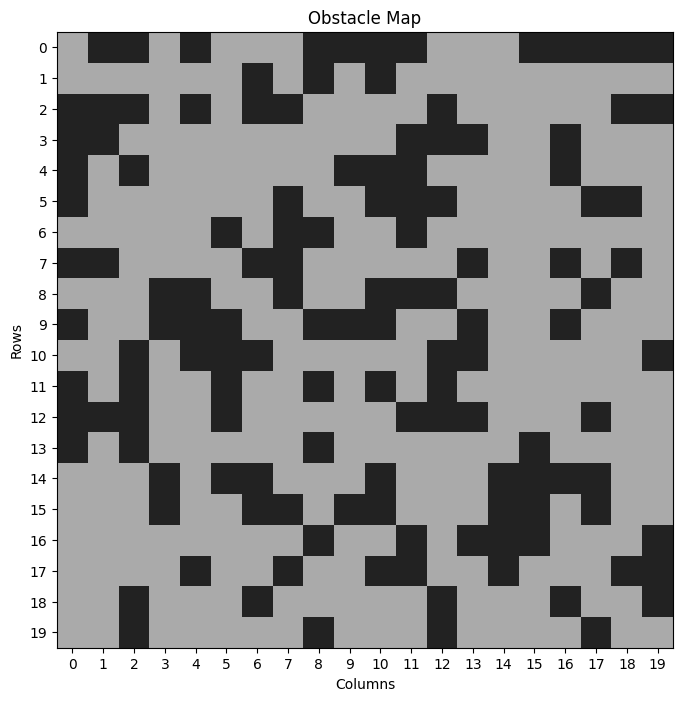

</div>

* We can imagine an agent traversing the map where the only available actions are UP, RIGHT, DOWN or LEFT. The agent cannot move beyond the borders of the map. 
* Elements in the map are indexed precisely as a 2D-array with coordinates given by (row, column). 
* Black squares are obstacles and are considered as non-states. Squares in gray are the states for our MDP. 
* The distance between two states A and B is the least number of steps that the agent has to take to get from A to B. For example if we want to go from (5,6) to (5,8) we need a path of four steps (around the corner north of the black square at (5,7)). Hence the distance between them is 4. 

Fortunately we don't need to manually enter the data for the map. Instead we may implicitly derive it from a dictionary provided in the following cell.


In [ ]:
import pickle, zlib, base64

compstr = "eJxtmUt27LgRRKXi/wf+Zl6BR70RreENapBL6KHP8UgreN6hF2IybwZAubsHIhGRiSJuoEDp9b+b//z3Hx/+379+//Pr4+vj+/ev31+f9/V9DasYVgybe3iXtd+3eg2NAWp3qR9SO9TPUFvUWbWLzzCjLlKTq4t3hJc0T3J1udVPnjMe+Bp+on6q9vUdizAGqNWzttIMqPX18xX3Lypq9TXfwcAY0Nd4R6NuY6m/frP29zUcfPi6r/dw0nyzd070ZCJzXvunvOUnreR9D3KfoiNyq1dkiobEp27urZrJkPB29zbNYUh4h3u7exveIe90dUc9Y7Mc93JfAgz2Cnwv4QNqxWZ5ffWojupSe9RBtYM/wuge91Exqm9yb/wO3IZE96Rugx7qIlTGpWwyIFUFtyFRsWZUVcFtSE/Qu2YyBgV0VXDbNfDtCaA3F5YEtntf1nH/oiH2pcO7vLrgrYT3FXhbr2g0kyHR3bnXlhgqfWc9gMvrNIchMXOfY6jjvqNi+BniWKKsSlA5RIMwaso4a3BWAv4KNUdi8MMD5+EVO96hNZyuHgJuSLdXu+eldg381Phq7usb1kxQZbwNeOuCvs5gmxKRIT3Dab0iB2VIVLQZclOCMqRnRL1mMgYloqYEdXt+lFzXhYUsWm3y0sVLZ0qTpkmZbhP3CxWrKvAe2dTiz0auxTGTJ4+zpFKLPKk0JRuDO8/56d59drec0o3Obg/gUl/fEZQh0VflGNq4f1FRq6LOMbTPQBvFpShbzWQM8Frvy1Ea3PGIYUCNb0Dr34CGvd+UHJZMuYVyoxyU0epezsuQqCCHzStyXobEp26aw0Bc9np7/7Trwvu9Za+3Qu9IA2/La7Mt6F8ZbPcMp1UACqf2ihyUIVGBlyMyeP4K5m+QUTp40egNA6VxenSutlJnrXvx2hl10TxLZtnKS/JSptg982hFW0lsXpFTMSQqSGLXTMaAJzq8b9cchoR3qs8YMNvpHXj+vegUALEAtgdsJ/SKpVY4xgAPtVG3Mbi9PtQatRffwT+jR/2xm2Hfx31UjKogralk1un167lQagzomNVhRICaMu8e3p0SaUPNmRmAfwXMN/QK4p4t38eW79nyvba8k/wafOP3bPlexLvwXt/RZwDDa1xtUeOMGPx06Dkd+sKzFzPj8hfKPfuV5b65UJTycoe4X2hYVQGQzSseyHq2KJX3lIdWfHrpQdGpaVBB5t5QGH1mDiMcBjF68DOWj9q62qHGi2z0F9kAs0E7Y/A9MLIHhnh5uftmyUyY8vpG1jeIQB9qZnR7uyY/3NtRM4IjL3aM+6g4/wbSGHtnZO+M4sKumfznyN4Z40+liV/jRi3dGVzD3hs6SnthGdwLdZA6eu2gPkPCm1wdUDPIyTvwRrwkL2VGE4xG8RPVzb0H4VGHnPO7vE1zGBLde6Y4xf1GxfHMYHomMcUvW0F00jnm+K7hfWLNnFWTzrHZ1Ulq7DSHeXkt6o+dNvvPSd7wxD0DbwIeEO8HWSK+xDCpJ2U4c9wv9K+qWDOi+Yl5KhC3jGgusA3pifnQTMYAD/X07gzbkOBzqtuAB5/KO252C+xmEZ1CfdCeC9c2E1wgOIuumPfuPfjP2tJzMO5QB/Whjt43aA5DuisW9yKbWfSdZFBdoDqLuzLZlIwxwNu8I2dioMM7XD29Ipid8lAza7sGbNjEhl2E17GB0LiUrbr4KyI90S96fTjS0teqr81IF14ii6ATRXoGsggsuIGXgLcIqXBPgm4MeIrZOyZ1GxLe4t6sbkPCS+4t7s14SZ+XXF1QN6lEsaPumudQQMaA2iPjT3EffT+2enqGl/RPQZ7Q18pxnHRUe37X8OUe91ERL7LVvcSLLClJvhwrOSVlsUQWPWqvTx68tldOhkTH8OzI/KfMeIVxKvznzHgtORlSSWgtORm4ClkIrSJ0ykPNfA1crOEjE9ogtIqhyL7ce1BexTCFlykb6PAg2XhFjRffhs3VVWofX7X+/qqtgsU2XVnoKkyCt/i0D5CrMD0Q3iq/FG339Q0aio7MZBOTU96D4iZSvvbgsMNhEynxe7n3YLn93G2bnx57IWpIMKndqzSTIdFdu9poDmOAh9p694P2plNm8927e8XGKbPFP1lu/BW2adtufnjsHBsbRwruG9p84uxFM0Wb1M3n393b8HZNe7i6f0cShkTfoT4DLB0fmeUBy120lcHLvUceu2griUpzGAO8yvtyEga2si8hdUBqLxQz4VuNM8BRXbU9asaIOnhHeLM86C2osWkP37TBdNfLzjle3oq6aYYt09zlZdK7dzxSOMTUKQWxE2KHmO6hPngfIrYHsdorKrxaz924WoupIdGH16j79jr19e51qJlmn7kd8oafpEfve1A/9OY7/MA4veJgCx86TE73Dt55h6g7/muYvG/BS5ptdTV5RXg5F7xV3QZyPBI4UA99/qFcDPh8xoeoGxfUR0KnUmDHnnA8C/86M45sTvFXNu2zr9XzdOozBnR06jAgow7ialxQSWJSHsbg/5IwwJY9fsLrLJxTZhkZnOKsDLZnHwf6yV+5pwA76Wt4UnRG0f3/JP78439aqkG+"
graph: dict = pickle.loads(zlib.decompress(base64.b64decode(compstr)))

The `graph` dictionary represents the map as key-value pairs, where the keys are states, i.e., coordinate tuples of the form (r, c) and the values are lists of the form [(r0, c0), (r1, c1), ... ] for the direct neighbors of a state (according to the actions available). Some examples: 
```python
list(graph.keys()) # All states as a list
graph[(19,0)] # Output -> [(18, 0), (19, 1)]
graph.items() # All state-List[neighbor] pairs
```

___

### Problem 5. Shortest Path with Value Iteration
**<TODO>** 

Our tasks are the following:
1. Define both a reward model and a Bellman operator that optimizes your model using value iteration. Note that there are several ways to do this; there isn't a single correct method. Recall that maximization and minimization can be used interchangeably in optimization with the appropriate adaptations. Don't be afraid to be creative.
2. Implement value iteration and supply a function that returns a look-up table which for each state gives the distance to state (19, 19). Present the table.
3. Use your values to extract an optimal path from (0,0) to (19,19), visualize the path in a plot of the obstacle map. How many steps are there in a shortest path from (0,0) to (19,19)? Do the same, but now from (19,11) to (19,19).
4. Extend your algorithm into a function which returns a shortest path between any two states. Visualize some examples. 

### Solution

___